## Import Packages

In [1]:
import csv
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt

## Load Dataset

In [2]:
FILEPATH = "data/data_sources_silver/clean_bgg.csv"
df_bgg = pd.read_csv(FILEPATH)
# Dropping data with missing values in the key columns
check_cols = ["complexity","num_ratings","num_owned","min_players",
                "max_players","min_playtime","max_playtime","min_age",
                "avg_rating", "categories", "num_comments"]
df_bgg = df_bgg.dropna(subset=check_cols)
print(f"Load BGG data: {len(df_bgg)} rows")
df_bgg.head()

Load BGG data: 136066 rows


,Unnamed: 0,id,name,year,min_players,max_players,min_playtime,max_playtime,min_age,complexity,...,num_owned,num_comments,num_wanting,num_wishing,categories,mechanics,designers,publishers,families,num_logged
0,0,224517,Brass: Birmingham,2018,2,4,60,120,14,3.8621,...,84099,7961,1746,21932,"Age of Reason, Economic, Industry / Manufactur...","Chaining, End Game Bonuses, Hand Management, I...","Gavan Brown, Matt Tolman, Martin Wallace","Roxley, Arclight Games, Board Game Rookie, Boa...","Cities: Birmingham (England), Components: Map ...",NaN
1,1,342942,Ark Nova,2021,1,4,90,150,14,3.7967,...,88969,8078,1063,17786,"Animals, Card Game, Environmental","Contracts, End Game Bonuses, Events, Grid Cove...",Mathias Wigge,"Feuerland Spiele, Capstone Games, CMON Global ...","Animals: Okapi, Components: Hexagonal Tiles, C...",NaN
2,2,161936,Pandemic Legacy: Season 1,2015,2,4,60,60,13,2.8279,...,89397,8605,813,15039,"Environmental, Medical","Action Points, Cooperative Game, Hand Manageme...","Rob Daviau, Matt Leacock","Z-Man Games, Asterion Press, Devir, Filosofia ...","Components: Map (Global Scale), Components: Mu...",NaN
3,3,174430,Gloomhaven,2017,1,4,60,120,14,3.9192,...,104567,11724,1161,22312,"Adventure, Exploration, Fantasy, Fighting, Min...","Action Queue, Action Retrieval, Campaign / Bat...",Isaac Childres,"Cephalofair Games, Albi, Albi Polska, Arclight...","Category: Dungeon Crawler, Components: Map (Ci...",NaN
4,4,397598,Dune: Imperium – Uprising,2023,1,6,60,120,13,3.5224,...,28509,2351,891,7872,"Movies / TV / Radio theme, Novel-based, Scienc...","Automatic Resource Growth, Card Play Conflict ...",Paul Dennen,"Dire Wolf, Arclight Games, Broadway Toys LTD, ...","Books: Dune, Game: Dune: Imperium, Misc: LongP...",NaN


## What Makes a Highly Rated Game?


Correlation with avg_rating:
complexity      0.391
min_age         0.214
max_playtime    0.129
min_playtime    0.124
num_comments    0.104
num_owned       0.094
num_ratings     0.082
max_players    -0.028
min_players    -0.041


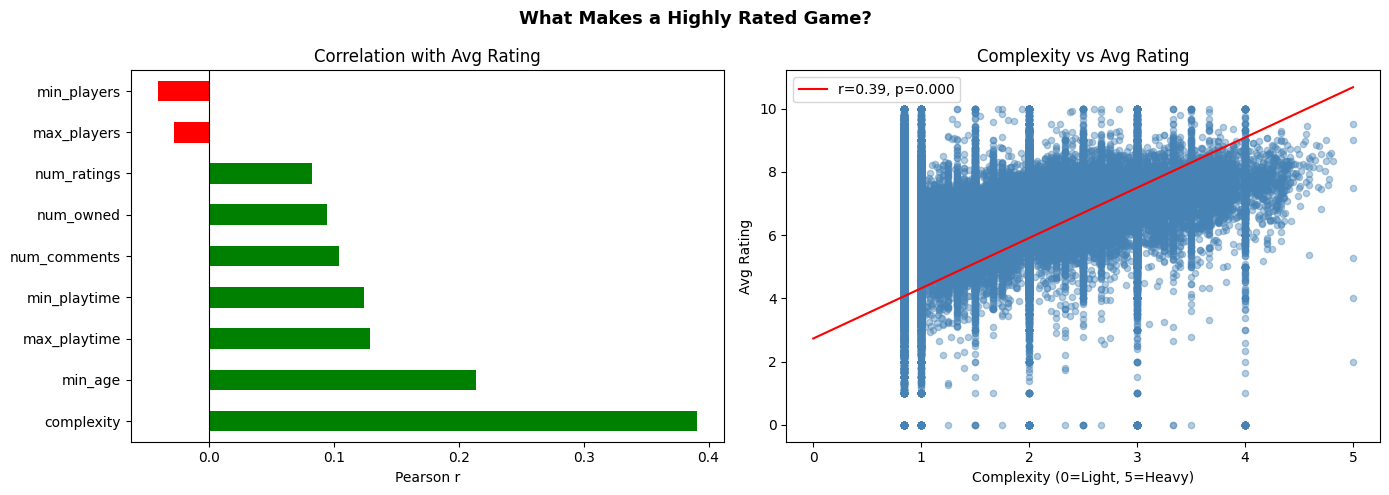

In [3]:
feature_cols = ["complexity","num_ratings","num_owned","min_players",
                "max_players","min_playtime","max_playtime","min_age",
                "num_comments"]
df_hrg = df_bgg[["avg_rating"] + feature_cols].copy().dropna()
corr = df_hrg.corr()["avg_rating"].drop("avg_rating").sort_values(ascending=False)

print("\nCorrelation with avg_rating:")
print(corr.round(3).to_string())
 
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("What Makes a Highly Rated Game?", fontsize=13, fontweight="bold")

corr.plot(kind="barh", ax=axes[0], color=["green" if v > 0 else "red" for v in corr])
axes[0].axvline(0, color="black", linewidth=0.8)
axes[0].set_title("Correlation with Avg Rating")
axes[0].set_xlabel("Pearson r")

axes[1].scatter(df_hrg["complexity"], df_hrg["avg_rating"], alpha=0.4, s=20, color="steelblue")
m, b, r_val, p, _ = stats.linregress(df_hrg["complexity"].dropna(), df_hrg["avg_rating"].dropna())
x_line = pd.Series([0, 5])
axes[1].plot(x_line, m * x_line + b, color="red", linewidth=1.5, label=f"r={r_val:.2f}, p={p:.3f}")
axes[1].set_title("Complexity vs Avg Rating")
axes[1].set_xlabel("Complexity (0=Light, 5=Heavy)")
axes[1].set_ylabel("Avg Rating")
axes[1].legend()
 
plt.tight_layout()
plt.savefig("bgg_hrg_plot.png", dpi=150, bbox_inches="tight")
plt.show()

## Categories: Quality vs Popularity

In [4]:
df_exploded = df_bgg.copy().assign(
    category=df_bgg["categories"].str.split(", ")
).explode("category")

df_cat = (
    df_exploded
    .groupby("category")
    .agg(
        n_games=("avg_rating", "count"),
        avg_rating=("avg_rating", "mean"),
        avg_comments=("num_comments", "mean"),
    )
    .reset_index()
)
print(f"Unique categories found: {len(df_cat)}")

Unique categories found: 80


In [5]:
# Define score with weight 50/50 on rating and comments
min_r, max_r = df_cat["avg_rating"].min(), df_cat["avg_rating"].max()
min_c, max_c = df_cat["avg_comments"].min(), df_cat["avg_comments"].max()

df_cat["score"] = (
    0.5 * (df_cat["avg_rating"] - min_r) / (max_r - min_r)
    + 0.5 * (df_cat["avg_comments"] - min_c) / (max_c - min_c)
)

df_cat = df_cat.sort_values("score", ascending=False).reset_index(drop=True)
df_cat[["category", "n_games", "avg_rating", "avg_comments", "score"]].head(15).round(3)

,category,n_games,avg_rating,avg_comments,score
0,Civilization,1122,5.907,269.619,0.903
1,Renaissance,753,6.131,227.216,0.859
2,City Building,1697,5.749,260.037,0.858
3,Territory Building,2021,5.859,223.265,0.806
4,Arabian,212,5.392,250.198,0.780
5,Post-Napoleonic,812,6.356,145.039,0.738
6,Age of Reason,531,6.493,132.254,0.737
7,Industry / Manufacturing,1158,5.359,182.314,0.644
8,Exploration,3588,5.629,155.257,0.637
9,Medieval,3844,5.748,139.296,0.627


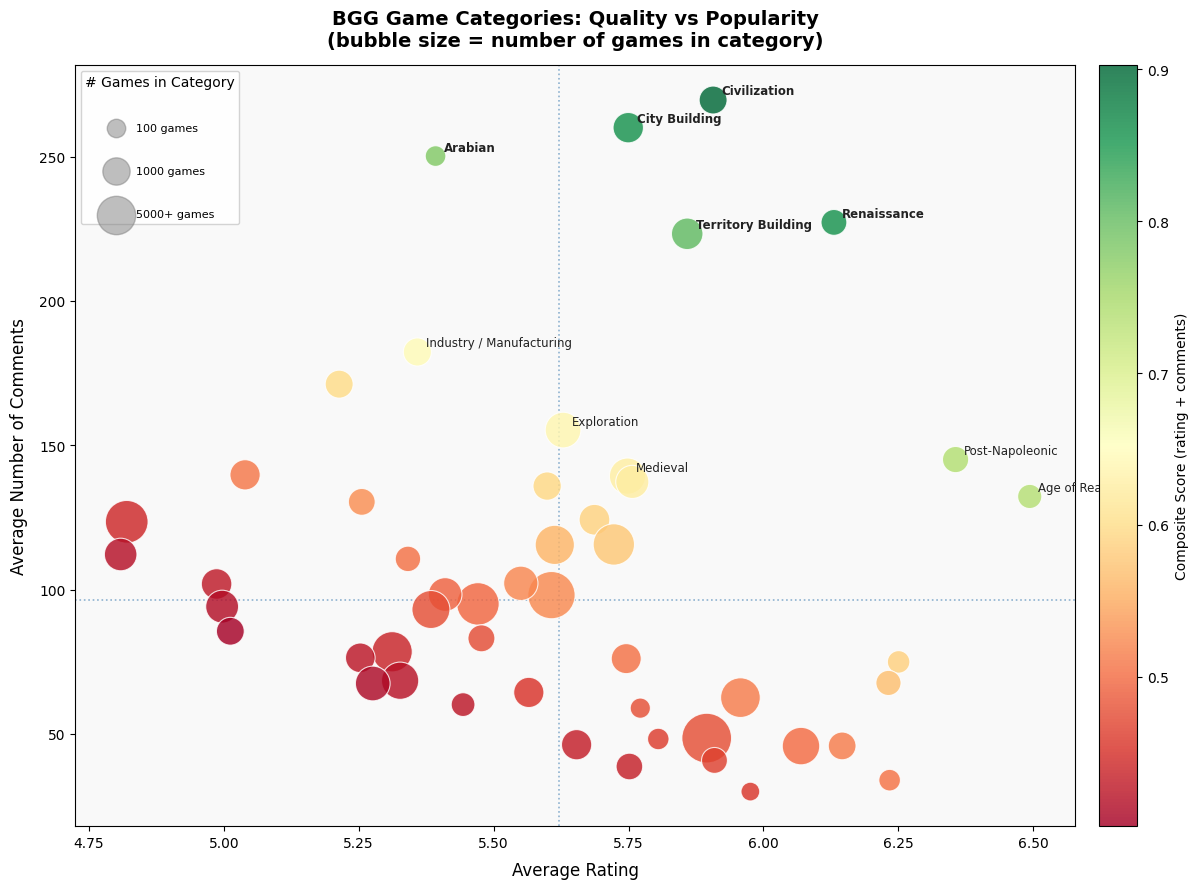

In [6]:
TOP_N = 50    # categories to plot
LABEL_N = 10  # categories to annotate

top = df_cat.head(TOP_N)
ratings = top["avg_rating"].values
comments = top["avg_comments"].values
n_games = top["n_games"].values
scores = top["score"].values
cats = top["category"].values

sizes = (np.sqrt(n_games) / np.sqrt(n_games.max())) * 1200 + 80

fig, ax = plt.subplots(figsize=(13, 9))
scatter = ax.scatter(
    ratings, comments,
    s=sizes, c=scores, cmap="RdYlGn",
    alpha=0.82, edgecolors="white", linewidths=0.8, zorder=3,
)   

for i, (cat, r, c) in enumerate(zip(cats, ratings, comments)):
    if i >= LABEL_N:
        break
    ax.annotate(
        cat, xy=(r, c), xytext=(6, 4), textcoords="offset points",
        fontsize=8.5, color="#222222", 
        fontweight="bold" if i < 5 else "normal",
    )   
    
ax.axvline(np.median(ratings), color="steelblue", linestyle=":", alpha=0.6, lw=1.2)
ax.axhline(np.median(comments), color="steelblue", linestyle=":", alpha=0.6, lw=1.2)

ax.set_facecolor("#f9f9f9")
fig.patch.set_facecolor("#ffffff")
ax.set_xlabel("Average Rating", fontsize=12, labelpad=8)
ax.set_ylabel("Average Number of Comments", fontsize=12, labelpad=8)
ax.set_title(
    "BGG Game Categories: Quality vs Popularity\n"
    "(bubble size = number of games in category)",
    fontsize=14, fontweight="bold", pad=14,
)

cbar = plt.colorbar(scatter, ax=ax, pad=0.02)
cbar.set_label("Composite Score (rating + comments)", fontsize=10)

for size_val, label in [(100, "100"), (1000, "1000"), (5000, "5000+")]:
    s = (np.sqrt(size_val) / np.sqrt(n_games.max())) * 1200 + 80
    ax.scatter([], [], s=s, c="gray", alpha=0.5, label=f"{label} games")

ax.legend(
    title="# Games in Category",
    loc="upper left",
    fontsize=8,
    framealpha=0.85,
    labelspacing=3.0,
)

plt.tight_layout()
plt.savefig("bgg_category_plot.png", dpi=150, bbox_inches="tight")
plt.show()